In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [81]:
courses_data = "../data/raw/Coursera_courses (1).csv"
reviews_data = "../data/raw/Coursera_reviews.csv"
courses = pd.read_csv(courses_data)
reviews = pd.read_csv(reviews_data)

In [82]:
print("Courses shape:", courses.shape)
print("Reviews shape:", reviews.shape)

Courses shape: (623, 4)
Reviews shape: (1454711, 5)


In [83]:
print("Courses:")
display(courses.head())
print(courses.info())
print("\nReview:")
display(reviews.head())
print(reviews.info())

Courses:


,name,institution,course_url,course_id
0,Machine Learning,Stanford University,https://www.coursera.org/learn/machine-learning,machine-learning
1,Indigenous Canada,University of Alberta,https://www.coursera.org/learn/indigenous-canada,indigenous-canada
2,The Science of Well-Being,Yale University,https://www.coursera.org/learn/the-science-of-...,the-science-of-well-being
3,Technical Support Fundamentals,Google,https://www.coursera.org/learn/technical-suppo...,technical-support-fundamentals
4,Become a CBRS Certified Professional Installer...,Google - Spectrum Sharing,https://www.coursera.org/learn/google-cbrs-cpi...,google-cbrs-cpi-training


<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   name         623 non-null    str  
 1   institution  623 non-null    str  
 2   course_url   623 non-null    str  
 3   course_id    623 non-null    str  
dtypes: str(4)
memory usage: 104.6 KB
None

Review:


,reviews,reviewers,date_reviews,rating,course_id
0,"Pretty dry, but I was able to pass with just t...",By Robert S,"Feb 12, 2020",4,google-cbrs-cpi-training
1,would be a better experience if the video and ...,By Gabriel E R,"Sep 28, 2020",4,google-cbrs-cpi-training
2,Information was perfect! The program itself wa...,By Jacob D,"Apr 08, 2020",4,google-cbrs-cpi-training
3,A few grammatical mistakes on test made me do ...,By Dale B,"Feb 24, 2020",4,google-cbrs-cpi-training
4,Excellent course and the training provided was...,By Sean G,"Jun 18, 2020",4,google-cbrs-cpi-training


<class 'pandas.DataFrame'>
RangeIndex: 1454711 entries, 0 to 1454710
Data columns (total 5 columns):
 #   Column        Non-Null Count    Dtype
---  ------        --------------    -----
 0   reviews       1454558 non-null  str  
 1   reviewers     1454711 non-null  str  
 2   date_reviews  1454711 non-null  str  
 3   rating        1454711 non-null  int64
 4   course_id     1454711 non-null  str  
dtypes: int64(1), str(4)
memory usage: 303.0 MB
None


In [84]:
print("Giá trị bị thiếu trong Courses:")
print(courses.isnull().sum())
print("\nGiá trị bị thiếu trong Reviews:")
print(reviews.isnull().sum())

Giá trị bị thiếu trong Courses:
name           0
institution    0
course_url     0
course_id      0
dtype: int64

Giá trị bị thiếu trong Reviews:
reviews         153
reviewers         0
date_reviews      0
rating            0
course_id         0
dtype: int64


In [85]:
print("Giá trị trùng lặp trong Courses:", courses.duplicated().sum())
print("Giá trị trùng lặp trong Reviews:", reviews.duplicated().sum())

Giá trị trùng lặp trong Courses: 0
Giá trị trùng lặp trong Reviews: 934764


In [86]:
duplicate_reviews = reviews[reviews.duplicated()]
duplicate_reviews.head(10)

,reviews,reviewers,date_reviews,rating,course_id
31,Solid presentation all the way through. I real...,By Logan D,"Sep 03, 2020",5,google-cbrs-cpi-training
32,Probably the best certification course I've ta...,By Luis M C,"Nov 21, 2019",5,google-cbrs-cpi-training
33,The ProctorU.com system took 2 times the amoun...,By scott w,"Sep 28, 2020",5,google-cbrs-cpi-training
34,Covered all of the required information in an ...,By Ryan H,"Aug 26, 2019",5,google-cbrs-cpi-training
35,"Great course, lectures were straight forward a...",By Samuel D,"Jan 24, 2020",5,google-cbrs-cpi-training
36,The course was straight forward and prepared m...,By Scot A W,"May 01, 2020",5,google-cbrs-cpi-training
37,Pretty well designed course. Few things on the...,By Jonathan L,"Jan 17, 2020",5,google-cbrs-cpi-training
38,"Great course, i have feedback about one questi...",By Geoff T,"Jul 21, 2019",5,google-cbrs-cpi-training
39,The course was fine but I never received an em...,By William J,"Jun 07, 2019",5,google-cbrs-cpi-training
40,Well presented course material that takes you ...,By Ariel R,"Sep 27, 2019",5,google-cbrs-cpi-training


In [87]:
duplicate_reviews = reviews[reviews.duplicated(keep=False)]
duplicate_reviews[duplicate_reviews["course_id"] == "google-cbrs-cpi-training"].sort_values("reviews").head(20)

,reviews,reviewers,date_reviews,rating,course_id
16,Course is easy enough if you have a basic back...,By Austin N,"Dec 27, 2019",5,google-cbrs-cpi-training
41,Course is easy enough if you have a basic back...,By Austin N,"Dec 27, 2019",5,google-cbrs-cpi-training
66,Course is easy enough if you have a basic back...,By Austin N,"Dec 27, 2019",5,google-cbrs-cpi-training
9,Covered all of the required information in an ...,By Ryan H,"Aug 26, 2019",5,google-cbrs-cpi-training
34,Covered all of the required information in an ...,By Ryan H,"Aug 26, 2019",5,google-cbrs-cpi-training
59,Covered all of the required information in an ...,By Ryan H,"Aug 26, 2019",5,google-cbrs-cpi-training
18,Easy to follow. Did a good job at teaching me ...,By Robert S,"Nov 07, 2019",5,google-cbrs-cpi-training
43,Easy to follow. Did a good job at teaching me ...,By Robert S,"Nov 07, 2019",5,google-cbrs-cpi-training
68,Easy to follow. Did a good job at teaching me ...,By Robert S,"Nov 07, 2019",5,google-cbrs-cpi-training
19,"Excellent Training, More than enough to pass t...",By Scott C,"Sep 02, 2020",5,google-cbrs-cpi-training


In [88]:
reviews = reviews.drop_duplicates()

print("Reviews shape after removing duplicates:", reviews.shape)
print("Remaining duplicates:", reviews.duplicated().sum())

Reviews shape after removing duplicates: (519947, 5)
Remaining duplicates: 0


In [89]:
print(reviews["rating"].value_counts().sort_index())

rating
1      6625
2      6070
3     17733
4     81401
5    408118
Name: count, dtype: int64


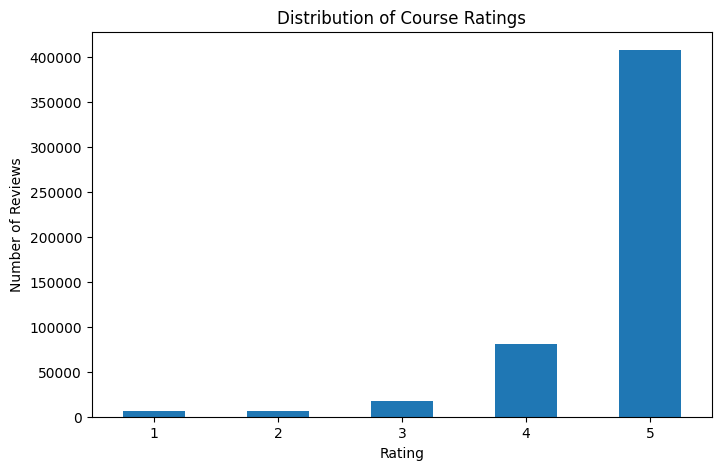

In [90]:
reviews["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Course Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [91]:
reviews_per_course = reviews["course_id"].value_counts()
reviews_per_course.describe()

count      604.000000
mean       860.839404
std       1608.604971
min          1.000000
25%        132.750000
50%        387.500000
75%        847.750000
max      15226.000000
Name: count, dtype: float64

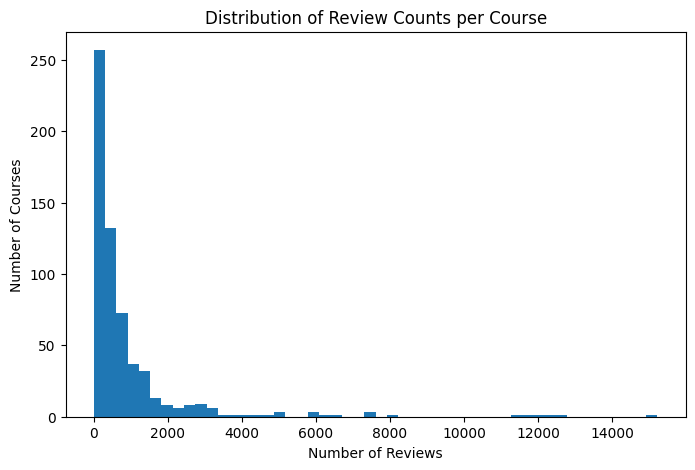

In [92]:
plt.figure(figsize=(8, 5))

plt.hist(reviews_per_course, bins=50)

plt.title("Distribution of Review Counts per Course")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Courses")

plt.show()

In [93]:
reviews_per_user = reviews["reviewers"].value_counts()
reviews_per_user.describe()

count    287808.000000
mean          1.806576
std           4.686566
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        1930.000000
Name: count, dtype: float64

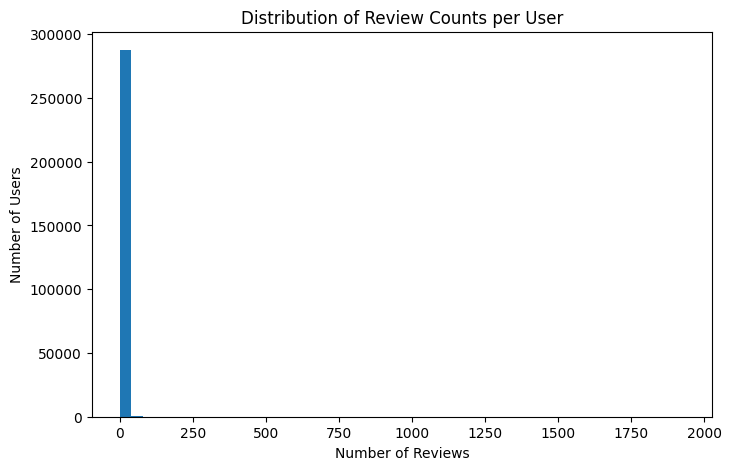

In [94]:
plt.figure(figsize=(8, 5))

plt.hist(reviews_per_user, bins=50)

plt.title("Distribution of Review Counts per User")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Users")

plt.show()

In [95]:
num_users = reviews["reviewers"].nunique()
num_courses = reviews["course_id"].nunique()
num_interactions = len(reviews)

total_possible = num_users * num_courses
sparsity = 1 - num_interactions / total_possible

print("Number of users:", num_users)
print("Number of courses:", num_courses)
print("Number of interactions:", num_interactions)
print("Sparsity: {:.4%}".format(sparsity))

Number of users: 287808
Number of courses: 604
Number of interactions: 519947
Sparsity: 99.7009%


In [96]:
print("Courses in courses dataset:", courses["course_id"].nunique())
print("Courses in reviews dataset:", reviews["course_id"].nunique())

print(
    "Courses in courses but not in reviews:",
    len(set(courses["course_id"]) - set(reviews["course_id"]))
)

Courses in courses dataset: 623
Courses in reviews dataset: 604
Courses in courses but not in reviews: 19


In [97]:
courses_without_reviews = courses[
    ~courses["course_id"].isin(reviews["course_id"])
]

display(courses_without_reviews)

,name,institution,course_url,course_id
57,Game Theory,Stanford University,https://www.coursera.org/learn/game-theory-1,game-theory-1
84,Organizational Analysis,Stanford University,https://www.coursera.org/learn/organizational-...,organizational-analysis
109,"Divide and Conquer, Sorting and Searching, and...",Stanford University,https://www.coursera.org/learn/algorithms-divi...,algorithms-divide-conquer
159,Circular Economy - Sustainable Materials Manag...,Delft University of Technology,https://www.coursera.org/learn/circular-economy,circular-economy
225,Fundamentals of Music Theory,The University of Edinburgh,https://www.coursera.org/learn/edinburgh-music...,edinburgh-music-theory
260,Unraveling the Cycling City,University of Amsterdam,https://www.coursera.org/learn/unraveling-the-...,unraveling-the-cycling-city
301,Digital Media and Marketing Strategies,University of Illinois at Urbana-Champaign,https://www.coursera.org/learn/marketing-plan,marketing-plan
359,The Changing Global Order,Universiteit Leiden,https://www.coursera.org/learn/changing-global...,changing-global-order
400,De-Mystifying Mindfulness,Universiteit Leiden,https://www.coursera.org/learn/mindfulness,mindfulness
404,Probabilistic Graphical Models 1: Representation,Stanford University,https://www.coursera.org/learn/probabilistic-g...,probabilistic-graphical-models


In [98]:
user_course_counts = reviews.groupby(
    ["reviewers", "course_id"]
).size()

print("Number of user-course pairs:", len(user_course_counts))
print("Pairs with multiple records:", (user_course_counts > 1).sum())

Number of user-course pairs: 506116
Pairs with multiple records: 9971


In [99]:
multiple_pairs = user_course_counts[
    user_course_counts > 1
]

display(multiple_pairs.head(10))

reviewers  course_id                         
By  A      food-and-health                       2
By  S S    chemicals-health                      2
By ???     google-kubernetes-engine              5
By A A A   machine-learning-with-python          2
By A R     matlab                                2
By A S     learning-how-to-learn                 2
           what-is-datascience                   2
By A S R   data-analysis-with-python             2
           python-for-applied-data-science-ai    2
By A. R    introduction-psychology               2
dtype: int64

In [100]:
display(
    reviews[
        (reviews["reviewers"] == "By ???") &
        (reviews["course_id"] == "google-kubernetes-engine")
    ]
)

,reviews,reviewers,date_reviews,rating,course_id
1288616,it was good but there were many error and cras...,By ???,"Apr 04, 2019",4,google-kubernetes-engine
1288774,It`s helpful to test,By ???,"Apr 03, 2019",4,google-kubernetes-engine
1288838,good,By ???,"Apr 03, 2019",4,google-kubernetes-engine
1289854,좋았습니다.,By ???,"Apr 02, 2019",5,google-kubernetes-engine
1289916,good,By ???,"Jun 04, 2019",5,google-kubernetes-engine


In [101]:
user_course_ratings = reviews.groupby(
    ["reviewers", "course_id"]
)["rating"].nunique()

print(
    "Pairs with multiple different ratings:",
    (user_course_ratings > 1).sum()
)

Pairs with multiple different ratings: 3884


In [102]:
print("Courses dataset:", courses.shape)
print("Reviews dataset after removing duplicates:", reviews.shape)

print("Unique reviewers:", reviews["reviewers"].nunique())
print("Unique courses in reviews:", reviews["course_id"].nunique())
print("Unique user-course pairs:", len(user_course_counts))

Courses dataset: (623, 4)
Reviews dataset after removing duplicates: (519947, 5)
Unique reviewers: 287808
Unique courses in reviews: 604
Unique user-course pairs: 506116


In [103]:
print(reviews[["reviewers", "course_id", "rating"]].dtypes)

reviewers      str
course_id      str
rating       int64
dtype: object


In [104]:
interactions = reviews[
    ["reviewers", "course_id", "rating"]
].copy()

display(interactions.head())

print("Interactions shape:", interactions.shape)

,reviewers,course_id,rating
0,By Robert S,google-cbrs-cpi-training,4
1,By Gabriel E R,google-cbrs-cpi-training,4
2,By Jacob D,google-cbrs-cpi-training,4
3,By Dale B,google-cbrs-cpi-training,4
4,By Sean G,google-cbrs-cpi-training,4


Interactions shape: (519947, 3)


In [105]:
print(multiple_pairs.value_counts().sort_index())

2     8094
3     1251
4      334
5      113
6       57
7       39
8       22
9       13
10      13
11       1
12       3
13       4
14       3
15       1
16       1
17       1
18       2
19       2
20       2
21       1
23       1
24       2
25       1
32       2
34       1
36       1
39       1
42       1
46       1
72       1
79       1
90       1
Name: count, dtype: int64


In [106]:
print(user_course_ratings.value_counts().sort_index())

rating
1    502232
2      3705
3       154
4        21
5         4
Name: count, dtype: int64


In [107]:
reviews["date_reviews"] = pd.to_datetime(
    reviews["date_reviews"],
    format="%b %d, %Y",
    errors="coerce"
)

print(reviews["date_reviews"].dtype)
print("Missing dates:", reviews["date_reviews"].isnull().sum())

datetime64[us]
Missing dates: 0


In [108]:
interactions = reviews[
    ["reviewers", "course_id", "rating", "date_reviews"]
].copy()

interactions = interactions.sort_values("date_reviews")

interactions = interactions.drop_duplicates(
    subset=["reviewers", "course_id"],
    keep="last"
)

print("Interactions shape:", interactions.shape)
print(
    "Duplicate user-course pairs:",
    interactions.duplicated(
        subset=["reviewers", "course_id"]
    ).sum()
)

display(interactions.head())

Interactions shape: (506116, 4)
Duplicate user-course pairs: 0


,reviewers,course_id,rating,date_reviews
241742,By Michelle F,learning-how-to-learn,5,2015-08-07
236771,By YUAN M,learning-how-to-learn,4,2015-08-07
623349,By C.A T,marketing-digital,5,2015-08-07
617555,By Erica B,marketing-digital,5,2015-08-07
591268,By Meenal K,physiology,5,2015-08-07


In [109]:
print("Number of interactions:", len(interactions))
print("Number of users:", interactions["reviewers"].nunique())
print("Number of courses:", interactions["course_id"].nunique())

print("\nRating distribution:")
print(interactions["rating"].value_counts().sort_index())

Number of interactions: 506116
Number of users: 287808
Number of courses: 604

Rating distribution:
rating
1      6433
2      5904
3     17201
4     79029
5    397549
Name: count, dtype: int64


In [110]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

interactions.to_csv(
    processed_dir / "interactions.csv",
    index=False
)

print("Saved to:", processed_dir / "interactions.csv")

Saved to: ..\data\processed\interactions.csv


In [111]:
num_users = interactions["reviewers"].nunique()
num_courses = interactions["course_id"].nunique()
num_interactions = len(interactions)

sparsity = 1 - num_interactions / (num_users * num_courses)

print("Number of users:", num_users)
print("Number of courses:", num_courses)
print("Number of interactions:", num_interactions)
print("Sparsity: {:.4%}".format(sparsity))

Number of users: 287808
Number of courses: 604
Number of interactions: 506116
Sparsity: 99.7089%


In [112]:
interactions = interactions.copy()

interactions["user_id"], user_values = pd.factorize(
    interactions["reviewers"],
    sort=True
)

interactions["course_idx"], course_values = pd.factorize(
    interactions["course_id"],
    sort=True
)

user_map = pd.DataFrame({
    "user_id": range(len(user_values)),
    "reviewers": user_values
})

course_map = pd.DataFrame({
    "course_idx": range(len(course_values)),
    "course_id": course_values
})

print("Number of users:", interactions["user_id"].nunique())
print("Number of courses:", interactions["course_idx"].nunique())

display(interactions.head())

Number of users: 287808
Number of courses: 604


,reviewers,course_id,rating,date_reviews,user_id,course_idx
241742,By Michelle F,learning-how-to-learn,5,2015-08-07,156224,339
236771,By YUAN M,learning-how-to-learn,4,2015-08-07,253256,339
623349,By C.A T,marketing-digital,5,2015-08-07,40366,355
617555,By Erica B,marketing-digital,5,2015-08-07,70562,355
591268,By Meenal K,physiology,5,2015-08-07,154037,413


In [113]:
user_counts = interactions["user_id"].value_counts()
course_counts = interactions["course_idx"].value_counts()

print("Users with fewer than 5 interactions:", (user_counts < 5).sum())
print("Courses with fewer than 5 interactions:", (course_counts < 5).sum())

Users with fewer than 5 interactions: 272806
Courses with fewer than 5 interactions: 7


In [114]:
filtered_interactions = interactions.copy()

while True:
    old_shape = filtered_interactions.shape

    user_counts = filtered_interactions["user_id"].value_counts()
    course_counts = filtered_interactions["course_idx"].value_counts()

    filtered_interactions = filtered_interactions[
        filtered_interactions["user_id"].isin(
            user_counts[user_counts >= 5].index
        )
        & filtered_interactions["course_idx"].isin(
            course_counts[course_counts >= 5].index
        )
    ]

    if filtered_interactions.shape == old_shape:
        break

print("Original interactions:", len(interactions))
print("Filtered interactions:", len(filtered_interactions))
print("Remaining users:", filtered_interactions["user_id"].nunique())
print("Remaining courses:", filtered_interactions["course_idx"].nunique())

Original interactions: 506116
Filtered interactions: 141773
Remaining users: 14999
Remaining courses: 585


In [115]:
num_users = filtered_interactions["user_id"].nunique()
num_courses = filtered_interactions["course_idx"].nunique()
num_interactions = len(filtered_interactions)

sparsity = 1 - num_interactions / (num_users * num_courses)

print("Users:", num_users)
print("Courses:", num_courses)
print("Interactions:", num_interactions)
print("Sparsity: {:.4%}".format(sparsity))

Users: 14999
Courses: 585
Interactions: 141773
Sparsity: 98.3842%


In [116]:
user_counts = filtered_interactions["user_id"].value_counts()
course_counts = filtered_interactions["course_idx"].value_counts()

print("Minimum user interactions:", user_counts.min())
print("Minimum course interactions:", course_counts.min())

print("Users:", filtered_interactions["user_id"].nunique())
print("Courses:", filtered_interactions["course_idx"].nunique())
print("Interactions:", len(filtered_interactions))

Minimum user interactions: 5
Minimum course interactions: 5
Users: 14999
Courses: 585
Interactions: 141773


In [117]:
print(filtered_interactions.columns)
print(filtered_interactions["date_reviews"].dtype)

Index(['reviewers', 'course_id', 'rating', 'date_reviews', 'user_id',
       'course_idx'],
      dtype='str')
datetime64[us]


In [118]:
filtered_interactions = filtered_interactions.sort_values(
    ["user_id", "date_reviews"]
).copy()

display(filtered_interactions.head(10))

,reviewers,course_id,rating,date_reviews,user_id,course_idx
311733,By B S K,python-data,5,2020-06-26,74,449
123752,By B S K,neural-networks-deep-learning,5,2020-07-02,74,388
365318,By B S K,deep-neural-network,5,2020-07-09,74,127
519570,By B S K,machine-learning-projects,4,2020-07-14,74,347
340951,By B S K,introduction-tensorflow,5,2020-08-29,74,316
559898,By B S K,convolutional-neural-networks-tensorflow,5,2020-09-10,74,95
829254,By B S K,tensorflow-sequences-time-series-and-prediction,5,2020-09-22,74,534
933503,By H A H,java-programming,4,2020-05-12,149,329
732887,By H A H,machine-learning-with-python,3,2020-05-19,149,348
296240,By H A H,python-data,5,2020-05-20,149,449


In [119]:
test_data = filtered_interactions.groupby("user_id").tail(1)

train_data = filtered_interactions.drop(test_data.index)

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

display(test_data.head())

Train shape: (126774, 6)
Test shape: (14999, 6)


,reviewers,course_id,rating,date_reviews,user_id,course_idx
829254,By B S K,tensorflow-sequences-time-series-and-prediction,5,2020-09-22,74,534
559427,By H A H,convolutional-neural-networks-tensorflow,4,2020-10-05,149,95
163734,By J K,what-is-datascience,5,2020-07-04,176,595
1171766,By K,python-programming-introduction,5,2020-08-10,187,461
1026507,By N B,wharton-introduction-spreadsheets-models,1,2019-04-21,271,585


In [120]:
print("Overlapping user-course pairs:")

train_pairs = set(
    zip(train_data["user_id"], train_data["course_idx"])
)

test_pairs = set(
    zip(test_data["user_id"], test_data["course_idx"])
)

print("Overlap:", len(train_pairs & test_pairs))

print(
    "Users in test without train history:",
    len(set(test_data["user_id"]) - set(train_data["user_id"]))
)

print("\nMissing values in train:")
print(train_data[["user_id", "course_idx", "rating"]].isnull().sum())

print("\nMissing values in test:")
print(test_data[["user_id", "course_idx", "rating"]].isnull().sum())

Overlapping user-course pairs:
Overlap: 0
Users in test without train history: 0

Missing values in train:
user_id       0
course_idx    0
rating        0
dtype: int64

Missing values in test:
user_id       0
course_idx    0
rating        0
dtype: int64


In [121]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

train_data.to_csv(
    processed_dir / "train.csv",
    index=False
)

test_data.to_csv(
    processed_dir / "test.csv",
    index=False
)

filtered_interactions.to_csv(
    processed_dir / "interactions_kcore5.csv",
    index=False
)

user_map.to_csv(
    processed_dir / "user_map.csv",
    index=False
)

course_map.to_csv(
    processed_dir / "course_map.csv",
    index=False
)

print("Saved train, test, filtered interactions, and ID mappings.")

Saved train, test, filtered interactions, and ID mappings.


In [122]:
train_check = pd.read_csv("../data/processed/train.csv")
test_check = pd.read_csv("../data/processed/test.csv")
interactions_check = pd.read_csv(
    "../data/processed/interactions_kcore5.csv"
)

print("Train shape:", train_check.shape)
print("Test shape:", test_check.shape)
print("K-core interactions shape:", interactions_check.shape)

print("\nMissing values in train:")
print(train_check[["user_id", "course_idx", "rating"]].isnull().sum())

print("\nMissing values in test:")
print(test_check[["user_id", "course_idx", "rating"]].isnull().sum())

Train shape: (126774, 6)
Test shape: (14999, 6)
K-core interactions shape: (141773, 6)

Missing values in train:
user_id       0
course_idx    0
rating        0
dtype: int64

Missing values in test:
user_id       0
course_idx    0
rating        0
dtype: int64
